# Double Avrami Paper

In [5]:
%run ../../../setup_workspace.py # ../ means level up 

# Functions

In [6]:
def Avrami(x, A, k, n):
    result = A * (1 - np.exp(-k * np.abs(x) ** n))  # или ограничить x
    result[x < 0] = 0
    return result
    
def Avrami_shifted(x, A, k, n, x0):
    res = Avrami(abs(x-x0), A, k, n)
    res[x < x0] *= 0
   
    return res
   
def Avraami_2(t, A, K1, n1, K2, n2):
    N = 300
    theta_arr = np.linspace(0, t, N)
 
    res = 0
 
    for theta in theta_arr:
        res += (1 - np.exp(-K2 * (t - theta) ** n2)) * theta ** (n1 - 1) * np.exp(-K1 * (theta ** n1)) * t / N
    return A * K1 * n1 * res
    
def Avraami_2_linspace(t,A, K1, n1, K2, n2):
    res = np.zeros(len(t))
 
    for i in range(len(t)):
        res[i] = Avraami_2(t[i],A, K1, n1, K2, n2)
    return res

def Model(t, A1, K1, n1, A2,  K2, n2):
    return Avrami(t, A1, K1, n1) + Avraami_2_linspace(t, A2, K1, n1, K2, n2)

def Model(t, A, r, K1, n1, K2, n2):
    return A * (r * Avrami(t, 1, K1, n1) + (1 - r) * Avraami_2_linspace(t, 1, K1, n1, K2, n2))

def read_data(path):
    return pd.read_csv(path, sep=str('\t'), names=['time', 'BB', 'cr'], skiprows=1)


func_lib = {
    'Avrami': Avrami,
    'Avrami_shifted': Avrami_shifted,
    'Avrami_2x' : Avraami_2_linspace
}

# Data

Text(0, 0.5, 'I  / a.u.')

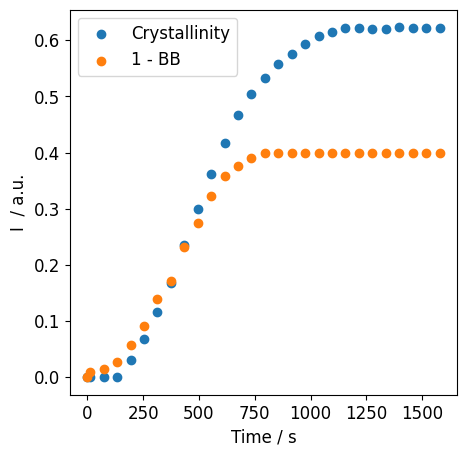

In [14]:
path = r"E:\PEG_PNIPAM crystallization\Samodelkin data\Kinetics\292_6_Cryst_at_10C.txt"
df = read_data(path)

k = 15

time = df['time'][:-k]
BB = df['BB'][:-k]
cr = df['cr'][:-k]

coef = 0.4

plt.figure(figsize=(5,5))
plt.scatter(time, cr, label='Crystallinity')
plt.scatter(time, coef * (1 - BB), label='1 - BB')

plt.legend()

plt.xlabel('Time / s')
plt.ylabel('I  / a.u.')

array([1.00437637e+00, 3.95228663e-07, 2.40742076e+00])

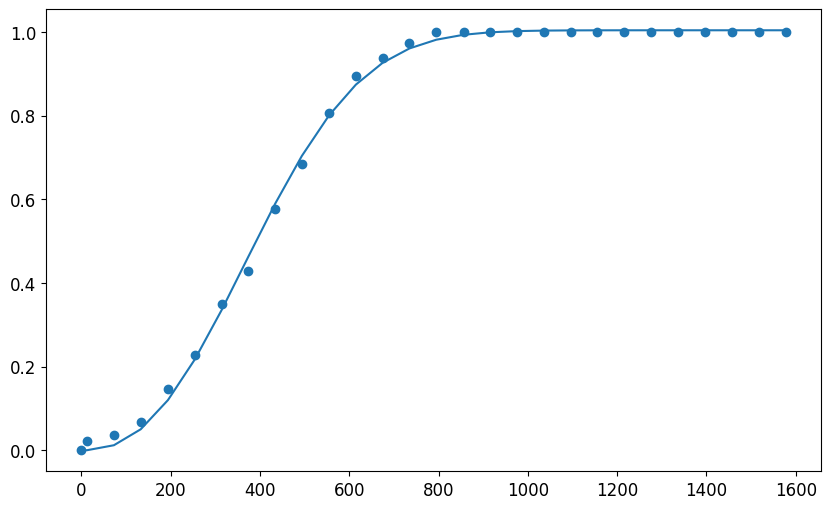

In [16]:
p, cov = curve_fit(Avrami, time, 1-BB)


plt.scatter(time, 1-BB)
plt.plot(time, Avrami(time, *p))

p 

array([1.00437637e+00, 3.95228663e-07, 2.40742076e+00])

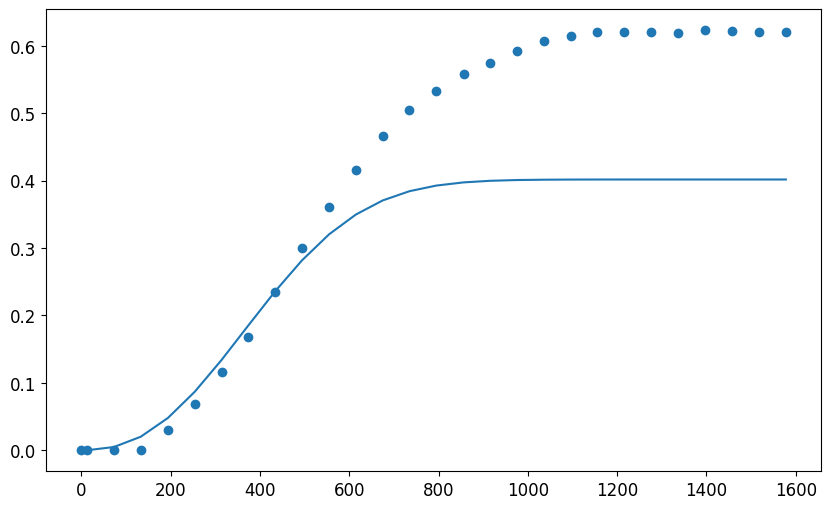

In [22]:
plt.scatter(time, cr)
plt.plot(time, 0.4 * Avrami(time, *p))

p 